# 🚢 타이타닉 생존자 예측 데이터셋 (Titanic Dataset) 컬럼 상세 가이드
### Titanic: Machine Learning from Disaster - Data Dictionary & Feature Engineering Guide

---

## 📌 개요 (Overview)
타이타닉 데이터셋은 1912년 4월 15일 빙산과 충돌해 침몰한 **타이타닉호(RMS Titanic)** 탑승객들의 인적 정보와 승선/티켓 정보를 바탕으로, 각 승객의 **생존 여부(`Survived`)를 예측하는 머신러닝 이진 분류(Binary Classification)** 문제의 대표적인 벤치마크 데이터셋입니다.

- **참조 파일**: `train.csv` (머신러닝 모델 학습용 데이터셋)
- **데이터 규모**: 총 **891행 (승객 891명)**, **12개 열 (피처 11개 + 타겟 1개)**
- **타겟 변수 (Target)**: `Survived` (0 = 사망, 1 = 생존)
- **전체 생존율**: 약 **38.38%** (사망 549명, 생존 342명)

## 1. 📊 전체 컬럼 종합 명세표 (Data Dictionary)

| 컬럼명 (Column) | 국문 설명 | 데이터 타입 | 변수 유형 | 결측치 수 (결측률) | 주요 값 / 범위 | 비고 및 머신러닝 활용 |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| **PassengerId** | 승객 고유 식별 번호 | int64 | 식별자 (ID) | 0 (0.00%) | 1 ~ 891 | 단순 인덱스, 모델 학습 시 반드시 제외 |
| **Survived** | 생존 여부 (타겟) | int64 | 이진 범주형 (Binary) | 0 (0.00%) | 0 (사망), 1 (생존) | 예측 목표 변수 (Target Label, Y) |
| **Pclass** | 티켓/객실 등급 | int64 | 순서형 범주형 (Ordinal) | 0 (0.00%) | 1 (1등석), 2 (2등석), 3 (3등석) | 사회경제적 지위(SES) 대리지표, 생존율과 직결 |
| **Name** | 승객 성명 | object (str) | 문자열 (Text) | 0 (0.00%) | `성, 호칭. 이름` 형태 | 호칭(Title: Mr, Miss, Master 등) 파생변수 추출 |
| **Sex** | 성별 | object (str) | 명목형 범주형 (Nominal) | 0 (0.00%) | `male` (남성), `female` (여성) | 생존 예측에 가장 영향력이 큰 핵심 피처 |
| **Age** | 승객 나이 | float64 | 연속형 수치 (Continuous) | 177 (19.87%) | 0.42세 ~ 80.00세 | 결측률 약 20%, 호칭/등급별 중앙값 대체 권장 |
| **SibSp** | 동반 형제자매/배우자 수 | int64 | 이산형 수치 (Discrete) | 0 (0.00%) | 0 ~ 8명 | 가족 규모(`FamilySize`) 파생변수 구성요소 |
| **Parch** | 동반 부모/자녀 수 | int64 | 이산형 수치 (Discrete) | 0 (0.00%) | 0 ~ 6명 | 직계 가족 수, 단독탑승(`IsAlone`) 생성 |
| **Ticket** | 티켓 식별 번호 | object (str) | 문자열 / 영숫자 | 0 (0.00%) | 영문접두사 + 숫자 | 티켓 공유 그룹(`Ticket_Count`) 파악 가능 |
| **Fare** | 탑승 요금 (운임) | float64 | 연속형 수치 (Continuous) | 0 (0.00%) | £0.00 ~ £512.33 | 우측 꼬리분포, 로그 변환(`log1p`) 권장 |
| **Cabin** | 객실 번호 | object (str) | 범주형 / 문자열 | 687 (77.10%) | 예: `C85`, `E46`, `G6` | 대규모 결측치, 구역(Deck) 추출 또는 결측여부 활용 |
| **Embarked** | 탑승 항구 | object (str) | 명목형 범주형 (Nominal) | 2 (0.22%) | `C` (셰르부르), `Q` (퀸스타운), `S` (사우샘프턴) | 결측치 2건은 최빈값('S')으로 대체, 원-핫 인코딩 대상 |

In [58]:
# [기본 검증] 표준 라이브러리(csv)를 이용한 train.csv 데이터 검증 및 결측치 현황 출력
import os
import csv

# 실행 경로에 맞게 train.csv 자동 탐색
csv_path = 'train.csv' if os.path.exists('train.csv') else os.path.join('Titanic', 'train.csv')

with open(csv_path, mode='r', encoding='utf-8') as f:
    reader = csv.DictReader(f)
    rows = list(reader)
    field_names = reader.fieldnames

total_rows = len(rows)
print(f'✅ 데이터 파일 로드 성공: [{csv_path}]')
print(f'   - 총 승객 수: {total_rows}명')
print(f'   - 컬럼 수: {len(field_names)}개\n')

print(f'{"컬럼명":<15} | {"결측치 수":<10} | {"결측률(%)":<10} | {"고유값 수":<10} | {"샘플 값"}')
print('-' * 72)
for col in field_names:
    vals = [r[col] for r in rows]
    missing_cnt = sum(1 for v in vals if v == '')
    unique_cnt = len(set(vals))
    sample_val = next(v for v in vals if v != '')
    missing_pct = (missing_cnt / total_rows) * 100
    print(f'{col:<15} | {missing_cnt:<10} | {missing_pct:>9.2f}% | {unique_cnt:<10} | {sample_val[:22]}')


✅ 데이터 파일 로드 성공: [train.csv]
   - 총 승객 수: 891명
   - 컬럼 수: 12개

컬럼명             | 결측치 수      | 결측률(%)     | 고유값 수      | 샘플 값
------------------------------------------------------------------------
PassengerId     | 0          |      0.00% | 891        | 1
Survived        | 0          |      0.00% | 2          | 0
Pclass          | 0          |      0.00% | 3          | 3
Name            | 0          |      0.00% | 891        | Braund, Mr. Owen Harri
Sex             | 0          |      0.00% | 2          | male
Age             | 177        |     19.87% | 89         | 22
SibSp           | 0          |      0.00% | 7          | 1
Parch           | 0          |      0.00% | 7          | 0
Ticket          | 0          |      0.00% | 681        | A/5 21171
Fare            | 0          |      0.00% | 248        | 7.25
Cabin           | 687        |     77.10% | 148        | C85
Embarked        | 2          |      0.22% | 4          | S


## 2. 🔍 각 컬럼별 심층 분석 및 머신러닝 인사이트

---

### (1) `PassengerId` - 승객 고유 식별 번호
- **데이터 타입**: 정수형 (1부터 891까지 1씩 순차 증가)
- **특징 및 의미**:
  - 데이터베이스의 기본 키(Primary Key) 역할을 하는 단순 일련번호입니다.
  - 승객의 생존 여부와는 아무런 인과관계가 없습니다.
- **머신러닝 처리 방법**:
  - ⚠️ 모델 학습 시 입력 피처(Feature)로 투입하면 모델이 단순 순번 패턴에 과적합(Overfitting)되므로 **반드시 제거(Drop)**해야 합니다.
  - 단, Kaggle 대회 등에서 최종 예측 결과(`submission.csv`)를 제출할 때 승객 식별용 인덱스로 보존합니다.

### (2) `Survived` - 생존 여부 (Target / Label)
- **데이터 타입**: 정수형 이진 변수 (`0` 또는 `1`)
- **값의 의미**:
  - `0`: 사망 (Perished / Did not survive) → **549명 (61.62%)**
  - `1`: 생존 (Survived) → **342명 (38.38%)**
- **머신러닝 관점**:
  - 본 프로젝트에서 모델이 맞춰야 하는 **목표 변수 (Target Label, $Y$)**입니다.
  - 사망과 생존 비율이 약 6:4로, 극단적인 희소 데이터셋(Imbalanced Dataset)은 아니지만 베이스라인 모델 구축 및 평가 시 단순 정확도(Accuracy)뿐만 아니라 **F1-Score, ROC-AUC, 정밀도/재현율(Precision/Recall)**을 균형 있게 모니터링해야 합니다.
  - 교차 검증 시 클래스 비율을 균등하게 분할하는 **`StratifiedKFold`** 사용이 필수적입니다.

### (3) `Pclass` - 티켓 및 객실 등급 (Passenger Ticket Class)
- **데이터 타입**: 정수형 순서 범주 (`1`, `2`, `3`)
- **값의 의미**:
  - `1`: 1등석 (Upper Class / 상류층 및 부유층)
  - `2`: 2등석 (Middle Class / 중산층)
  - `3`: 3등석 (Lower Class / 노동자 및 이민자 계층)
- **실제 탑승객 수 및 생존율 통계**:
  - **1등석**: 216명 탑승 / 136명 생존 (**생존율 63.0%**)
  - **2등석**: 184명 탑승 / 87명 생존 (**생존율 47.3%**)
  - **3등석**: 491명 탑승 / 119명 생존 (**생존율 24.2%**)
- **인사이트 & 머신러닝 활용**:
  - 승객의 **사회경제적 지위(Socio-Economic Status, SES)**를 직접 대변하는 변수입니다.
  - 상위 등급 객실은 선박 상층부에 위치하여 구명보트 접근성이 높았던 반면, 3등석은 선박 깊은 곳에 위치하여 탈출 경로가 지연되었습니다.
  - $1 > 2 > 3$의 순서 관계가 있으므로 정수형(Ordinal) 그대로 사용하거나, 원-핫 인코딩(One-Hot Encoding)을 적용할 수 있습니다.

### (4) `Name` - 승객 성명
- **데이터 타입**: 문자열 (텍스트)
- **기록 형식**: `성(Last Name), 호칭(Title). 이름(First Name) (처녀 시절 성)`
  - 예: `Braund, Mr. Owen Harris`
  - 예: `Cumings, Mrs. John Bradley (Florence Briggs Thayer)`
- **피처 엔지니어링의 핵심 (호칭 추출, Title)**:
  - 원본 문자열은 고유값이 891개로 모델이 직접 학습할 수 없지만, 정규식(`r'([A-Za-z]+)\.'`)을 통해 **호칭(Title)**을 추출하면 승객의 연령대, 성별, 사회적 신분을 알 수 있습니다.
  - 주요 호칭별 생존율 분포:
    - `Mr`: 성인 남성 (가장 낮은 생존율, 약 **15.7%**)
    - `Miss`: 미혼 여성 (높은 생존율, 약 **69.8%**)
    - `Mrs`: 기혼 여성 (가장 높은 생존율, 약 **79.2%**)
    - `Master`: 14세 이하의 남자 어린이 (남성이지만 생존율 약 **57.5%**!)
    - 기타 희귀 호칭(Rare Titles): `Rev`(성직자, 생존율 0%), `Dr`, `Col`, `Major`(장교), `Sir`, `Countess`(귀족) 등
  - ⭐ **활용처**: 추출된 호칭은 **`Age` 결측치를 그룹별로 정밀하게 추정**하는 데 결정적인 기준이 됩니다.

### (5) `Sex` - 성별
- **데이터 타입**: 문자열 이진 범주 (`male`, `female`)
- **탑승객 수 및 생존율 통계**:
  - **여성 (`female`)**: 314명 탑승 / 233명 생존 (**생존율 74.20%**)
  - **남성 (`male`)**: 577명 탑승 / 109명 생존 (**생존율 18.89%**)
- **인사이트 & 모델링 영향**:
  - 구조 당시 엄격히 준수된 **"여성과 어린이 우선 (Women and children first)"** 원칙으로 인해, 생존 여부를 가르는 **가장 강력한 단일 피처**입니다.
  - 수치형으로 이진 인코딩(`female: 1, male: 0`)하여 모델에 투입합니다.

### (6) `Age` - 승객 나이
- **데이터 타입**: 실수형 (0.42세 영아부터 80세 노인까지)
- **결측치 현황**: **177건 (전체의 19.87%)** - 약 20%의 상당한 결측률
- **특징 및 생존 패턴**:
  - 나이가 소수점인 경우(예: 0.42, 0.67)는 1세 미만 영아를 뜻하거나, 당시 추정치입니다.
  - 5세 이하 영유아(특히 `Master` 호칭)의 생존율이 매우 높았습니다.
  - 20~30대 청년층 남성의 사망률이 가장 높았습니다.
- **결측치 처리 전략 (Imputation)**:
  1. *단순 대체*: 전체 중앙값(28.0세) 또는 평균(29.7세) 사용 (다소 거침).
  2. *정밀 대체 (Best Practice)*: **`Pclass`와 `Title` 그룹별 중앙값**으로 세분화 대체.
     - 예: `Master` 그룹의 나이 중앙값은 약 3.5세, `Mrs` 그룹은 35세, `Mr` 그룹은 30세
  3. *구간화(Binning)*: 연속형 나이를 영유아(0~5), 소아(6~12), 청소년(13~18), 청년(19~35), 중년(36~60), 노년(61 이상)의 범주로 그룹화.

### (7) `SibSp` - 동반 형제자매 및 배우자 수
- **데이터 타입**: 정수형 이산 변수 (0 ~ 8)
- **정의**:
  - **Sibling (형제자매)**: 형제, 자매, 의붓형제, 의붓자매 (Stepbrother, Stepsister)
  - **Spouse (배우자)**: 남편, 아내 (약혼자나 내연 관계는 제외)
- **분포**:
  - 0명: 608명 (68.2%) - 혼자 탑승한 승객이 다수
  - 1명: 209명 (23.5%) - 주로 부부 또는 형제 1명 동행
  - 2명 이상: 74명 (8.3%)

---

### (8) `Parch` - 동반 부모 및 자녀 수
- **데이터 타입**: 정수형 이산 변수 (0 ~ 6)
- **정의**:
  - **Parent (부모)**: 어머니, 아버지
  - **Child (자녀)**: 아들, 딸, 의붓아들, 의붓딸 (단, 유모나 친척과만 탑승한 아이의 Parch는 0)
- **분포**:
  - 0명: 678명 (76.1%)
  - 1명: 118명 (13.2%)
  - 2명: 80명 (9.0%)
  - 3~6명: 15명

---

### ⭐ `SibSp` + `Parch` 결합 파생변수 (가족 공학, Family Engineering)
승객이 혼자 탑승했는지, 아니면 가족과 함께 탑승했는지는 탈출 행동에 지대한 영향을 미쳤습니다.

1. **`FamilySize` (가족 총원)**: `SibSp + Parch + 1` (승객 본인 포함)
   - **1명 (나홀로 승객)**: 생존율 **30.35%** (조력자가 없어 불리)
   - **2~4명 (소가족)**: 생존율 **약 55% ~ 72%** (서로를 챙기며 안전하게 보트에 탑승)
   - **5명 이상 (대가족)**: 생존율 **약 0% ~ 20%** (혼란 속에서 온 가족이 모이기 어려워 탈출 지연)
2. **`IsAlone` (단독 탑승 여부)**: `FamilySize == 1`이면 1, 아니면 0
   - 이진 변수로 단순화하여 모델의 비선형 관계 해석을 돕습니다.

### (9) `Ticket` - 티켓 식별 번호
- **데이터 타입**: 문자열 (알파벳 접두사 + 일련번호, 예: `A/5 21171`, `PC 17599`, `373450`)
- **특징**:
  - 결측치는 0건이며, 총 681종의 고유 티켓 번호가 존재합니다.
  - 동일한 티켓 번호를 여러 승객이 함께 사용하는 경우가 있습니다 (가족 단위, 친구, 고용인-시종 그룹).
- **파생변수 아이디어**:
  - **`Ticket_Frequency` (동일 티켓 공유 인원)**: 동일 티켓 번호를 몇 명이 공유했는지를 카운트하여 가족 관계 외의 '동행 그룹'을 파악할 수 있습니다.
  - **`Ticket_Prefix`**: 티켓 앞자리의 알파벳 접두사를 범주형 피처로 추출.

### (10) `Fare` - 탑승 요금 (운임)
- **데이터 타입**: 실수형 (당시 영국 파운드화, £0.00 ~ £512.33)
- **분포 특징**:
  - 중앙값은 £14.45이지만 최댓값은 £512.33로 **극단적인 우측 꼬리(Right-skewed) 왜도 분포**를 보입니다.
  - 요금이 0원인 승객(선박 회사 직원, 악단, 초청 승객 등)도 15명 존재합니다.
- **주의사항 및 전처리 기법**:
  - **그룹 티켓 합산 요금 보정**: 티켓을 여러 명이 공유한 경우 요금이 1인분이 아닌 그룹 전체 요금으로 기재되어 있습니다. 1인당 순수 운임을 산출하려면 `Fare_Per_Person = Fare / Ticket_Count`를 적용할 수 있습니다.
  - 선형 모델이나 거리 기반 모델(KNN, SVM)을 위해 **로그 변환 (`np.log1p(Fare)`)**을 수행하여 왜도를 완화하거나, 분위수 기반 구간화(`FareBin`)를 수행합니다.

### (11) `Cabin` - 객실 번호
- **데이터 타입**: 문자열 (예: `C85`, `E46`, `G6`, `C23 C25 C27`)
- **결측치 현황**: **687건 (전체의 77.10%)** - 전체 피처 중 결측률이 가장 높음
- **구조적 의미**:
  - 맨 앞의 영문자는 **선실의 층(Deck)**을 의미합니다: `A`, `B`, `C`, `D`, `E`, `F`, `G`, `T`
  - `A~C` 덱은 보트 덱과 가까운 최상층(주로 1등석 부유층)에 위치했습니다.
- **피처 엔지니어링 접근법**:
  1. **`Has_Cabin` (선실 번호 기록 유무)**: 결측치가 아니면 1, 결측치면 0
     - 객실 번호가 기록된 승객(주로 1등석): **생존율 66.67%**
     - 객실 번호가 결측인 승객(주로 2/3등석): **생존율 29.99%**
     - 결측 여부 자체가 생존을 강력하게 구분 짓는 정보(Informative Missingness)입니다.
  2. **`Deck` (선실 구역 추출)**: 맨 앞 알파벳 글자만 추출하고, 결측치는 `'M'`(Missing)으로 범주화.

### (12) `Embarked` - 승선 항구
- **데이터 타입**: 1글자 영문 범주형 (`C`, `Q`, `S`)
- **항구별 의미 및 생존율 통계**:
  - **`C` (Cherbourg, 프랑스 셰르부르)**: 168명 탑승 (**생존율 55.36%**)
  - **`Q` (Queenstown, 아일랜드 퀸스타운, 현 코브)**: 77명 탑승 (**생존율 38.96%**)
  - **`S` (Southampton, 영국 사우샘프턴)**: 644명 탑승 (**생존율 33.70%**)
- **결측치 현황**: **단 2건 (0.22%)** (티켓 113572, 요금 £80인 1등석 승객 2명)
- **인사이트 & 전처리**:
  - 셰르부르(C)에서 승선한 승객은 유럽 본토의 부유층(1등석) 비율이 높아 생존율이 가장 높았습니다.
  - 사우샘프턴(S)은 타이타닉의 출발지로 전체 승객의 72%가 탑승한 메인 항구입니다.
  - 결측치 2건은 데이터 왜곡 없이 **최빈값인 `'S'`**로 채우는 것이 표준적입니다.
  - 명목형 변수이므로 원-핫 인코딩(One-Hot Encoding)을 적용합니다.

## 3. 🧪 컬럼별 통계 및 생존율 집계 실습 (Python Code Cell)
아래 코드를 실행하면 파이썬 표준 라이브러리를 통해 각 컬럼별 탑승 인원과 생존율 통계를 바로 확인할 수 있습니다.

In [59]:
# 컬럼별 생존율 및 세부 분포 통계 계산 스크립트
import os
import csv
from collections import defaultdict

csv_path = 'train.csv' if os.path.exists('train.csv') else os.path.join('Titanic', 'train.csv')

with open(csv_path, mode='r', encoding='utf-8') as f:
    data = list(csv.DictReader(f))

def print_survival_breakdown(feature_name, key_func=None):
    stats = defaultdict(lambda: {'total': 0, 'survived': 0})
    for row in data:
        val = row[feature_name] if key_func is None else key_func(row)
        stats[val]['total'] += 1
        if row['Survived'] == '1':
            stats[val]['survived'] += 1
            
    print(f'=== [{feature_name}] 별 탑승객 및 생존율 통계 ===')
    print(f'{"구분":<20} | {"탑승 인원":<10} | {"생존자 수":<10} | {"생존율(%)"}')
    print('-' * 60)
    for k in sorted(stats.keys(), key=lambda x: str(x)):
        tot = stats[k]['total']
        surv = stats[k]['survived']
        rate = (surv / tot) * 100 if tot > 0 else 0
        print(f'{str(k):<20} | {tot:<10} | {surv:<10} | {rate:>7.2f}%')
    print() # 줄바꿈

# 1. 성별(Sex)별 생존율
print_survival_breakdown('Sex')

# 2. 객실 등급(Pclass)별 생존율
print_survival_breakdown('Pclass')

# 3. 탑승 항구(Embarked)별 생존율
print_survival_breakdown('Embarked', key_func=lambda r: r['Embarked'] if r['Embarked'] != '' else 'Missing(결측)')

# 4. 객실 번호 유무(Has_Cabin)별 생존율
print_survival_breakdown('Has_Cabin', key_func=lambda r: 'Cabin 있음' if r['Cabin'] != '' else 'Cabin 없음(결측)')

# 5. 가족 규모 그룹(FamilySize_Group)별 생존율
def family_group(r):
    f_size = int(r['SibSp']) + int(r['Parch']) + 1
    if f_size == 1:
        return '1. Alone (1인/단독)'
    elif 2 <= f_size <= 4:
        return f'2. Small Family ({f_size}인 소가족)'
    else:
        return f'3. Large Family ({f_size}인 대가족)'

print_survival_breakdown('FamilySize_Group', key_func=family_group)


=== [Sex] 별 탑승객 및 생존율 통계 ===
구분                   | 탑승 인원      | 생존자 수      | 생존율(%)
------------------------------------------------------------
female               | 314        | 233        |   74.20%
male                 | 577        | 109        |   18.89%

=== [Pclass] 별 탑승객 및 생존율 통계 ===
구분                   | 탑승 인원      | 생존자 수      | 생존율(%)
------------------------------------------------------------
1                    | 216        | 136        |   62.96%
2                    | 184        | 87         |   47.28%
3                    | 491        | 119        |   24.24%

=== [Embarked] 별 탑승객 및 생존율 통계 ===
구분                   | 탑승 인원      | 생존자 수      | 생존율(%)
------------------------------------------------------------
C                    | 168        | 93         |   55.36%
Missing(결측)          | 2          | 2          |  100.00%
Q                    | 77         | 30         |   38.96%
S                    | 644        | 217        |   33.70%

=== [Has_Cabin] 별 탑승객 및 생존율 통

## 4. 💡 판다스(Pandas)를 활용한 실전 피처 엔지니어링 파이프라인 예시
머신러닝 모델 학습을 위해 결측치를 보정하고 파생변수를 추가하는 표준 판다스 코드입니다.
*(환경에 pandas가 설치되어 있지 않은 경우 `!pip install pandas` 명령으로 설치 후 실행할 수 있습니다.)*

In [60]:
# Pandas 기반 피처 엔지니어링 실전 예시 파이프라인
import os

try:
    import pandas as pd
    import re

    csv_path = 'train.csv' if os.path.exists('train.csv') else os.path.join('Titanic', 'train.csv')
    df = pd.read_csv(csv_path)

    # [1] Name 컬럼에서 호칭(Title) 추출 및 정리
    df['Title'] = df['Name'].apply(lambda x: re.search(r'([A-Za-z]+)\.', x).group(1))
    rare_titles = ['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona']
    df['Title'] = df['Title'].replace(rare_titles, 'Rare')
    df['Title'] = df['Title'].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})

    # [2] 가족 관련 파생변수 생성 (FamilySize, IsAlone)
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

    # [3] Cabin 유무 및 Deck 추출
    df['Has_Cabin'] = df['Cabin'].notnull().astype(int)
    df['Deck'] = df['Cabin'].fillna('M').apply(lambda x: x[0])

    # [4] 결측치 대체: Embarked는 최빈값('S'), Age는 Title 그룹별 중앙값
    df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
    df['Age'] = df.groupby('Title')['Age'].transform(lambda x: x.fillna(x.median()))

    # [5] Sex 이진 인코딩
    df['Sex_Code'] = df['Sex'].map({'male': 0, 'female': 1})

    print('✅ 피처 엔지니어링 완료 데이터프레임 미리보기 (상위 10행):')
    display_cols = [
        'PassengerId', 'Survived', 'Pclass', 
        'Name', 'Title',  # 원본 Name과 추출된 Title을 나란히 확인
        'Sex_Code', 'Age', 'FamilySize', 'IsAlone', 'Fare', 'Has_Cabin', 'Embarked'
    ]
    print(df[display_cols].head(10))
    print('\n결측치 잔여 현황:')
    print(df[display_cols].isnull().sum())
except ImportError:
    print('ℹ️ pandas 라이브러리가 현재 환경에 설치되어 있지 않습니다.')
    print('터미널 또는 주피터에서 `pip install pandas`를 실행하면 위 코드를 실행할 수 있습니다.')


✅ 피처 엔지니어링 완료 데이터프레임 미리보기 (상위 10행):
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   
5            6         0       3   
6            7         0       1   
7            8         0       3   
8            9         1       3   
9           10         1       2   

                                                Name   Title  Sex_Code   Age  \
0                            Braund, Mr. Owen Harris      Mr         0  22.0   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...     Mrs         1  38.0   
2                             Heikkinen, Miss. Laina    Miss         1  26.0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)     Mrs         1  35.0   
4                           Allen, Mr. William Henry      Mr         0  35.0   
5                                   Moran, Mr. James      Mr         0  30.0   
6      

## 5. 🎯 결론 및 머신러닝 모델링 체크리스트

1. **불필요한 컬럼 제거 (Drop Features)**:
   - `PassengerId` (단순 고유번호)
   - 원본 `Name` (호칭 추출 후 제거)
   - 원본 `Ticket` (티켓 공유 카운트 추출 후 제거)
   - `Cabin` (결측치 77%로 희소하므로 `Has_Cabin` 또는 `Deck` 생성 후 원본 제거)
2. **결측치 처리 (Imputation)**:
   - `Embarked`: 2건 결측 → 최빈값(`'S'`)으로 채움
   - `Age`: 177건 결측 → `Title` 및 `Pclass` 기준 그룹별 중앙값으로 정밀 대체 권장
3. **범주형 변수 인코딩 (Encoding)**:
   - `Sex`: 이진 인코딩 (`female: 1, male: 0`)
   - `Embarked`, `Title`, `Deck`: 원-핫 인코딩(`pd.get_dummies` 또는 `OneHotEncoder`)
   - `Pclass`: 서수형(1, 2, 3) 순서 유지 또는 원-핫 인코딩
4. **스케일링 및 왜도 보정**:
   - `Fare`: 긴 꼬리 분포 완화를 위해 `np.log1p(Fare)` 로그 변환 권장
5. **교차 검증 (Cross Validation)**:
   - 생존율 38.4%의 타겟 비율을 유지하기 위해 **`StratifiedKFold`** 분할 전략을 사용하는 것이 필수적입니다.

In [61]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     891 non-null    str    
 12  Title        891 non-null    str    
 13  FamilySize   891 non-null    int64  
 14  IsAlone      891 non-null    int64  
 15  Has_Cabin    891 non-null    int64  
 16  Deck         891 non-null    str    
 17  Sex_Code     891 non-null    int64  
dtypes: float64(2), int64(9), str(7)
memory usage: 125.4 KB


In [62]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,FamilySize,IsAlone,Has_Cabin,Deck,Sex_Code
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr,2,0,0,M,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs,2,0,1,C,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss,1,1,0,M,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs,2,0,1,C,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr,1,1,0,M,0


In [63]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,FamilySize,IsAlone,Has_Cabin,Deck,Sex_Code
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S,Rare,1,1,0,M,0
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S,Miss,1,1,1,B,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,21.0,1,2,W./C. 6607,23.45,NaN,S,Miss,4,0,0,M,1
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C,Mr,1,1,1,C,0
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q,Mr,1,1,0,M,0


In [64]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'Title', 'FamilySize',
       'IsAlone', 'Has_Cabin', 'Deck', 'Sex_Code'],
      dtype='str')

In [65]:
df.index

RangeIndex(start=0, stop=891, step=1)

In [66]:
df.values

array([[1, 0, 3, ..., 0, 'M', 0],
       [2, 1, 1, ..., 1, 'C', 1],
       [3, 1, 3, ..., 0, 'M', 1],
       ...,
       [889, 0, 3, ..., 0, 'M', 1],
       [890, 1, 1, ..., 1, 'C', 0],
       [891, 0, 3, ..., 0, 'M', 0]], shape=(891, 18), dtype=object)

In [67]:
df.Age

0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
886    27.0
887    19.0
888    21.0
889    26.0
890    32.0
Name: Age, Length: 891, dtype: float64

In [68]:
df.Embarked

0      S
1      C
2      S
3      S
4      S
      ..
886    S
887    S
888    S
889    C
890    Q
Name: Embarked, Length: 891, dtype: str

In [69]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [70]:
# 1. 처리 전 최빈값 및 결측치 개수 확인
print("최빈값:", df['Embarked'].mode()[0])
print("처리 전 결측치 수:", df['Embarked'].isnull().sum())

# 2. 결측치 대체
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# 3. 처리 후 결과 확인 (0이 나오면 정상)
print("처리 후 결측치 수:", df['Embarked'].isnull().sum())
print("\n항구별 탑승 인원 분포:")
print(df['Embarked'].value_counts(dropna=False))


최빈값: S
처리 전 결측치 수: 0
처리 후 결측치 수: 0

항구별 탑승 인원 분포:
Embarked
S    646
C    168
Q     77
Name: count, dtype: int64


In [71]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     891 non-null    str    
 12  Title        891 non-null    str    
 13  FamilySize   891 non-null    int64  
 14  IsAlone      891 non-null    int64  
 15  Has_Cabin    891 non-null    int64  
 16  Deck         891 non-null    str    
 17  Sex_Code     891 non-null    int64  
dtypes: float64(2), int64(9), str(7)
memory usage: 125.4 KB


In [72]:
# 1. 모델링에 사용할 최종 피처 정의
feature_cols = [
    'Pclass',       # 객실 등급 (1, 2, 3)
    'Sex_Code',     # 성별 (female: 1, male: 0)
    'Age',          # 나이
    'Fare',         # 요금
    'Embarked',     # 탑승 항구 (C, Q, S)
    'Title',        # 호칭 (Mr, Miss, Mrs, Master, Rare)
    'FamilySize',   # 가족 수
    'IsAlone',      # 1인 단독 탑승 여부 (1, 0)
    'Has_Cabin'     # 객실 번호 보유 여부 (1, 0)
]

# 2. X, y 분리
X = df[feature_cols].copy()
y = df['Survived']

# 3. 범주형 문자열 변수(Embarked, Title) 원-핫 인코딩
X = pd.get_dummies(X, columns=['Embarked', 'Title'], drop_first=True)

print("모델 입력 피처 형태:", X.shape)
X.head()


모델 입력 피처 형태: (891, 13)


,Pclass,Sex_Code,Age,Fare,FamilySize,IsAlone,Has_Cabin,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
0,3,0,22.0,7.2500,2,0,0,False,True,False,True,False,False
1,1,1,38.0,71.2833,2,0,1,False,False,False,False,True,False
2,3,1,26.0,7.9250,1,1,0,False,True,True,False,False,False
3,1,1,35.0,53.1000,2,0,1,False,True,False,False,True,False
4,3,0,35.0,8.0500,1,1,0,False,True,False,True,False,False


In [73]:
from sklearn.preprocessing import RobustScaler, StandardScaler, MinMaxScaler

# 1. 각 특성에 맞는 스케일러 객체 생성
scaler_robust = RobustScaler()      # 이상치에 강한 로버스트 스케일러
scaler_standard = StandardScaler()  # 평균 0, 표준편차 1 표준화 스케일러
scaler_minmax = MinMaxScaler()      # 0 ~ 1 범위 정규화 스케일러

# 2. 가장 적합한 방식으로 컬럼별 스케일링 적용
# (1) Fare: 극단적 이상치 존재 -> RobustScaler
X['Fare'] = scaler_robust.fit_transform(X[['Fare']])

# (2) Age: 정규분포 형태 -> StandardScaler (평균화)
X['Age'] = scaler_standard.fit_transform(X[['Age']])

# (3) FamilySize: 명확한 범위(1~11) -> MinMaxScaler (정규화)
X['FamilySize'] = scaler_minmax.fit_transform(X[['FamilySize']])

# 3. 스케일링 결과 확인
print("✅ 스케일링 완료된 수치형 컬럼 요약 통계:")
print(X[['Fare', 'Age', 'FamilySize']].describe())


✅ 스케일링 완료된 수치형 컬럼 요약 통계:
             Fare           Age  FamilySize
count  891.000000  8.910000e+02  891.000000
mean     0.768745  2.232906e-16    0.090460
std      2.152200  1.000562e+00    0.161346
min     -0.626005 -2.184796e+00    0.000000
25%     -0.283409 -6.328696e-01    0.000000
50%      0.000000  4.581525e-02    0.000000
75%      0.716591  4.228624e-01    0.100000
max     21.562738  3.816287e+00    1.000000


In [74]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------------------------------------
# 1. 학습용(Train) / 평가용(Test) 데이터셋 분할 (8:2 비율)
# (타겟 비율을 보존하기 위해 stratify=y 필수 적용)
# -------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"학습 데이터 크기: {X_train.shape}, 테스트 데이터 크기: {X_test.shape}\n")

# -------------------------------------------------------------
# 2. 추천 모델 생성 및 학습 (Gradient Boosting)
# -------------------------------------------------------------
best_model = GradientBoostingClassifier(
    n_estimators=100,      # 트리 개수
    learning_rate=0.05,     # 학습률 (과적합 완화를 위해 0.05 설정)
    max_depth=3,           # 트리 최대 깊이
    random_state=42
)

best_model.fit(X_train, y_train)

# -------------------------------------------------------------
# 3. 테스트 데이터 예측 및 성능 평가
# -------------------------------------------------------------
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

test_acc = accuracy_score(y_test, y_pred)
test_auc = roc_auc_score(y_test, y_proba)

print("🎯 [테스트 데이터 최종 평가 결과]")
print(f"- 정확도 (Accuracy) : {test_acc * 100:.2f}%")
print(f"- ROC-AUC 점수     : {test_auc:.4f}")
print("\n[상세 분류 리포트 (Precision / Recall / F1-Score)]")
print(classification_report(y_test, y_pred, target_names=['사망(0)', '생존(1)']))

# -------------------------------------------------------------
# 4. 피처 중요도 (Feature Importances) 확인
# -------------------------------------------------------------
importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)

print("\n💡 [모델이 중요하게 판단한 상위 7개 피처]")
print(importances.head(7))


학습 데이터 크기: (712, 13), 테스트 데이터 크기: (179, 13)

🎯 [테스트 데이터 최종 평가 결과]
- 정확도 (Accuracy) : 81.56%
- ROC-AUC 점수     : 0.8551

[상세 분류 리포트 (Precision / Recall / F1-Score)]
              precision    recall  f1-score   support

       사망(0)       0.82      0.90      0.86       110
       생존(1)       0.81      0.68      0.74        69

    accuracy                           0.82       179
   macro avg       0.81      0.79      0.80       179
weighted avg       0.82      0.82      0.81       179


💡 [모델이 중요하게 판단한 상위 7개 피처]
Title_Mr      0.464548
Fare          0.129734
Pclass        0.118454
Age           0.065875
FamilySize    0.065726
Title_Rare    0.047043
Sex_Code      0.044796
dtype: float64


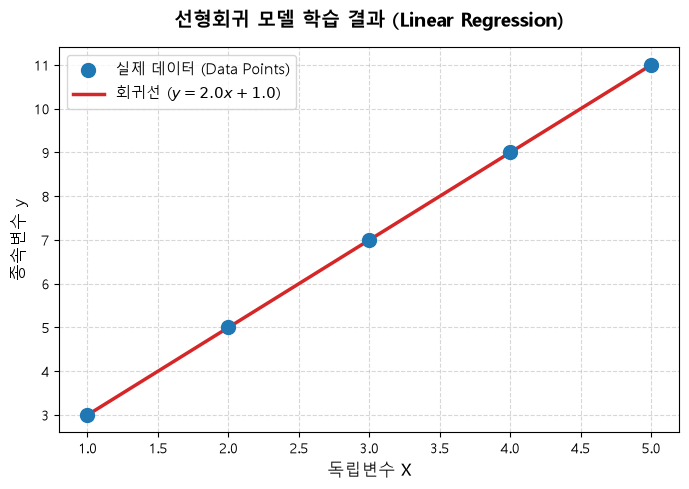

In [75]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# -------------------------------------------------------------
# 1. 윈도우 환경 한글 폰트 및 마이너스 부호 깨짐 방지 설정
# -------------------------------------------------------------
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

# -------------------------------------------------------------
# 2. 데이터 준비 및 모델 학습
# -------------------------------------------------------------
X = np.array([1, 2, 3, 4, 5]).reshape(-1, 1)
y = np.array([3, 5, 7, 9, 11])

model = LinearRegression()
model.fit(X, y)

# 회귀선 그리기용 예측값 계산
y_pred = model.predict(X)

# -------------------------------------------------------------
# 3. 그래프 그리기
# -------------------------------------------------------------
plt.figure(figsize=(8, 5))

# (1) 실제 데이터 포인트 (산점도)
plt.scatter(X, y, color='#1f77b4', s=100, label='실제 데이터 (Data Points)', zorder=5)

# (2) 학습된 회귀선 (직선)
plt.plot(
    X, y_pred, color='#d62728', linewidth=2.5, 
    label=f'회귀선 ($y = {model.coef_[0]:.1f}x + {model.intercept_:.1f}$)'
)

# (3) 타이틀 및 축 레이블, 그리드, 범례 설정
plt.title('선형회귀 모델 학습 결과 (Linear Regression)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('독립변수 X', fontsize=12)
plt.ylabel('종속변수 y', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11)

# 화면에 출력
plt.show()


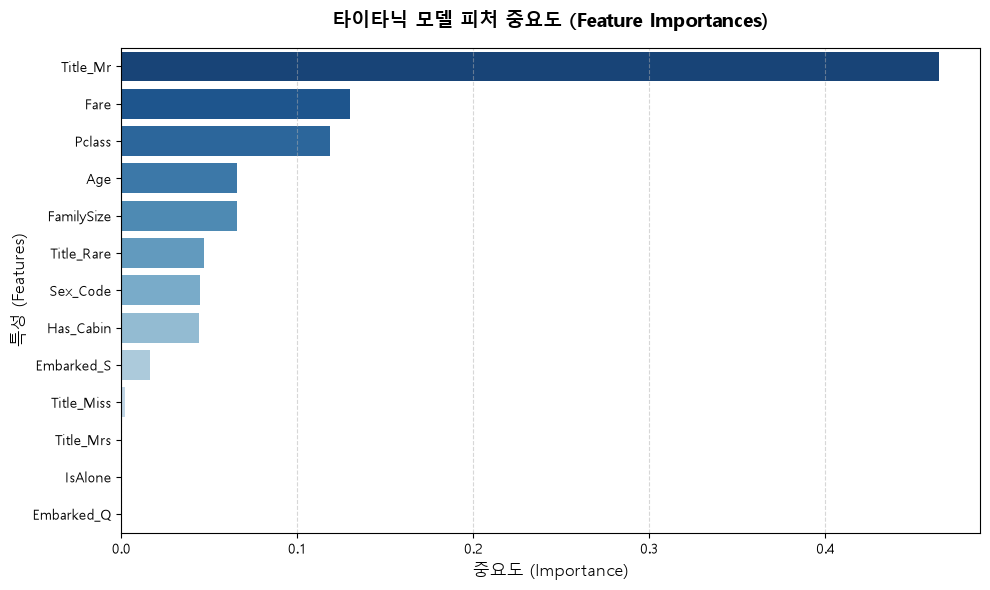

In [76]:
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

# 피처 중요도 정렬
plt.figure(figsize=(10, 6))
sns.barplot(
    x=importances.values, 
    y=importances.index, 
    hue=importances.index, 
    legend=False, 
    palette='Blues_r'
)

plt.title('타이타닉 모델 피처 중요도 (Feature Importances)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('중요도 (Importance)', fontsize=12)
plt.ylabel('특성 (Features)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


In [77]:
# 1. 타이타닉 X 데이터프레임 다시 정의
feature_cols = ['Pclass', 'Sex_Code', 'Age', 'Fare', 'Embarked', 'Title', 'FamilySize', 'IsAlone', 'Has_Cabin']
X = df[feature_cols].copy()
X = pd.get_dummies(X, columns=['Embarked', 'Title'], drop_first=True)

# 2. 스케일링 적용 (데이터프레임 형태 유지)
from sklearn.preprocessing import RobustScaler, StandardScaler, MinMaxScaler
X['Fare'] = RobustScaler().fit_transform(X[['Fare']])
X['Age'] = StandardScaler().fit_transform(X[['Age']])
X['FamilySize'] = MinMaxScaler().fit_transform(X[['FamilySize']])

# 3. 이제 상관계수 계산이 정상 작동합니다!
corr = X.corr()


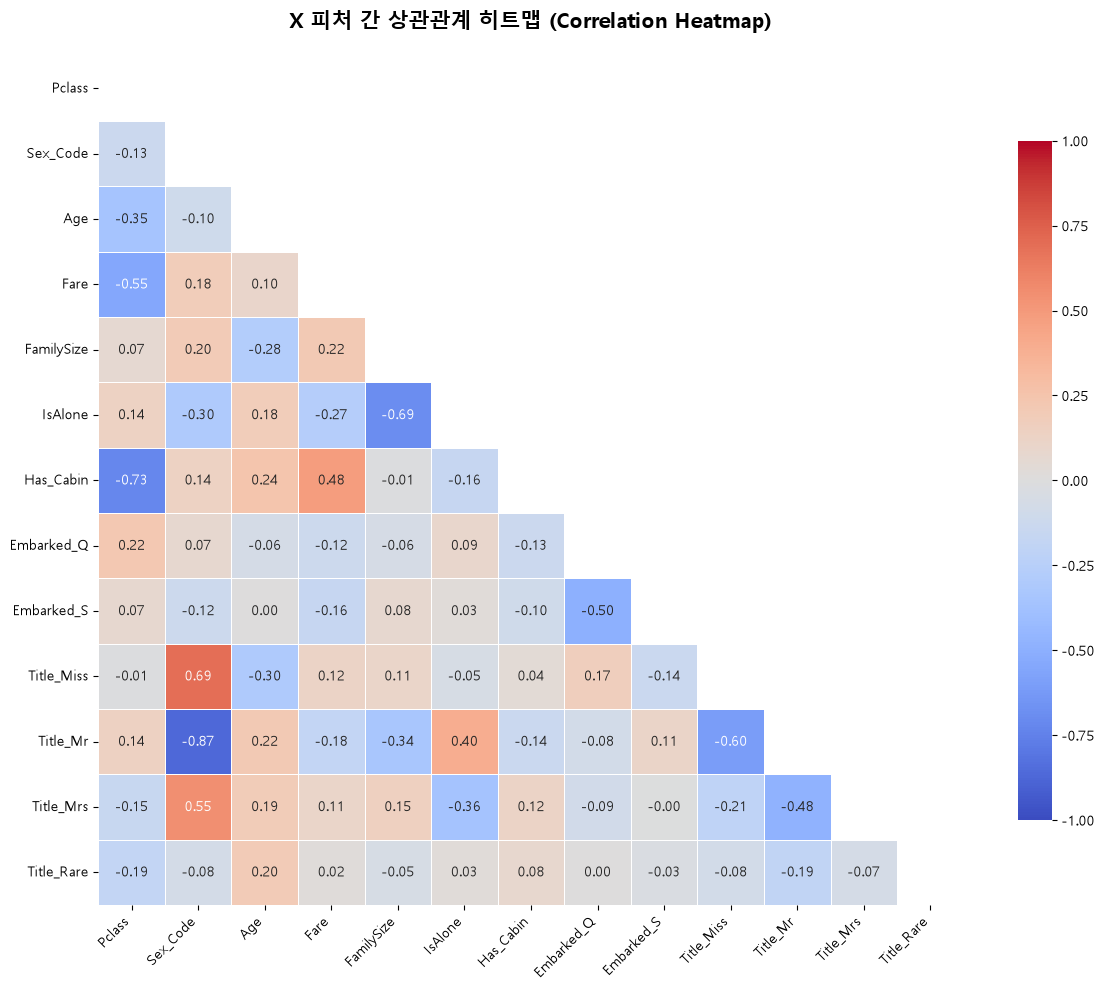

In [78]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------------------------------------
# 1. 한글 폰트 및 마이너스 기호 설정 (Windows 환경)
# -------------------------------------------------------------
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

# -------------------------------------------------------------
# 2. 상관계수 행렬 계산
# -------------------------------------------------------------
corr = X.corr()

# -------------------------------------------------------------
# 3. 상단 대칭 영역 마스크 생성 (중복 제거용)
# -------------------------------------------------------------
mask = np.triu(np.ones_like(corr, dtype=bool))

# -------------------------------------------------------------
# 4. 히트맵 시각화
# -------------------------------------------------------------
plt.figure(figsize=(12, 10))

sns.heatmap(
    corr,
    mask=mask,               # 상단 삼각형 숨기기
    annot=True,              # 상관계수 수치 표시
    fmt='.2f',               # 소수점 둘째 자리까지 표기
    cmap='coolwarm',         # 양(빨강)/음(파랑) 상관관계를 직관적으로 보여주는 컬러맵
    vmin=-1.0, vmax=1.0,     # 상관계수 범위 (-1 ~ +1) 고정
    linewidths=0.5,          # 셀 간 경계선
    cbar_kws={'shrink': 0.8} # 컬러바 크기 조절
)

plt.title('X 피처 간 상관관계 히트맵 (Correlation Heatmap)', fontsize=15, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()


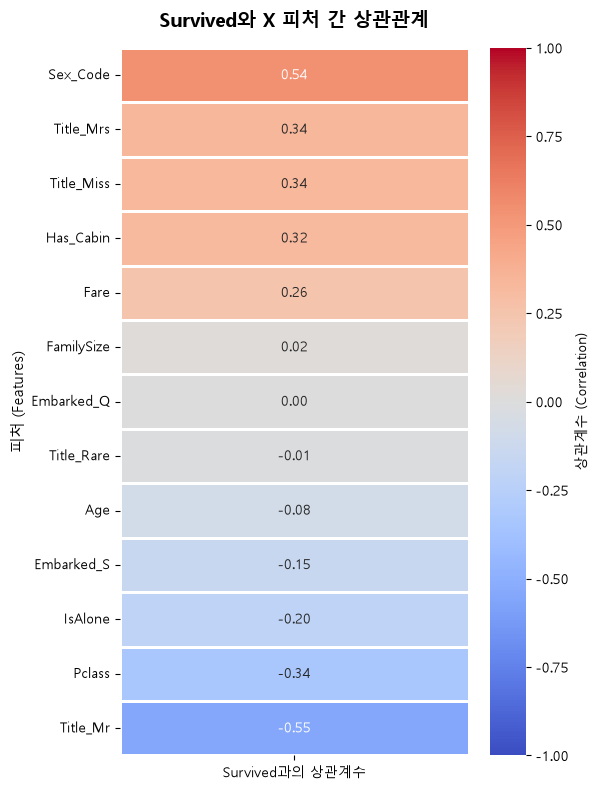

In [81]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------------------------------------
# 1. 윈도우 한글 폰트 설정
# -------------------------------------------------------------
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

# -------------------------------------------------------------
# 2. df['Survived']를 직접 전달하여 상관계수 계산 및 내림차순 정렬
# -------------------------------------------------------------
corr_with_survived = X.corrwith(df['Survived']).sort_values(ascending=False).to_frame(name='Survived과의 상관계수')

# -------------------------------------------------------------
# 3. 1열 히트맵 시각화
# -------------------------------------------------------------
plt.figure(figsize=(6, 8))

sns.heatmap(
    corr_with_survived,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1.0, vmax=1.0,
    cbar_kws={'label': '상관계수 (Correlation)'},
    linewidths=1.0
)

plt.title('Survived와 X 피처 간 상관관계', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('피처 (Features)', fontsize=11)
plt.tight_layout()
plt.show()
